# EfficientNetB0 PyTorch Local GPU Training — May11
**Pipeline:** EfficientNetB0 ImageNet backbone -> 128-d embedding head -> 6-class classifier  
Training uses local laptop GPU, Keras-equivalent augmentation, full metric reporting, plots, inference timing, model size/parameter reporting, and saved embeddings/results.  
All outputs saved to `EfficientNetB0_May11_Results/`.  
Dataset: May11 rebalanced split — 1,750 train / 250 val / 500 test per class (15,000 total).


In [1]:
# ================================================
# Cell 1 — Imports & Config
# ================================================
# ── Standard library ──────────────────────────────────────────
# os, pathlib : file path construction and directory management
# time        : wall-clock timing for inference benchmarking
import os
import time
from pathlib import Path


# ── Scientific computing ───────────────────────────────────────
# numpy  : array operations, random sampling, metric aggregation
# pandas : tabular results and CSV export
# matplotlib: training curve and metric plot generation
# tqdm   : progress bars for training and evaluation loops
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ── PyTorch core ───────────────────────────────────────────────
# torch           : tensor operations and autograd engine
# torch.nn        : layer definitions (Linear, Dropout, Identity)
# torch.optim     : Adam optimiser
# torch.nn.functional: softmax for probability conversion
# DataLoader/Subset: batch loading and index-based subset sampling
# torchvision     : pretrained EfficientNetB0 weights and transforms
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


# ── Evaluation metrics ─────────────────────────────────────────
# sklearn: classification report, confusion matrix, per-class
#         precision/recall/F1 for full evaluation pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)


# ── Dataset and output paths ───────────────────────────────────
# Dataset is pre-split into Training / Validation / Testing.
# All results (model weights, plots, CSVs) are saved to OUTPUT_DIR.
# ── Paths ──────────────────────────────────────
BASE_DATASET = "/home/jenarththan/Desktop/FYP/May11/Dataset"
TRAIN_PATH   = os.path.join(BASE_DATASET, "Training")
VAL_PATH     = os.path.join(BASE_DATASET, "Validation")
TEST_PATH    = os.path.join(BASE_DATASET, "Testing")

NOTEBOOK_DIR = "/home/jenarththan/Desktop/FYP/May11/Notebooks"
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, "EfficientNetB0_May11_Results")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")


# ── Training hyperparameters ───────────────────────────────────
# IMG_SIZE=224      : EfficientNetB0 standard input resolution
# BATCH_SIZE=32     : balances GPU memory usage and gradient noise
# EPOCHS=50         : maximum epochs (early stopping usually stops earlier)
# PATIENCE=5        : stop if val_loss does not improve for 5 consecutive epochs
# MIN_EPOCHS_BEFORE_STOP=20: ensures meaningful training before early stop
# LR=1e-5           : low learning rate for stable fine-tuning of pretrained weights
# SEED=42           : fixed random seed for fully reproducible splits and weights
# EMBED_DIM=128     : dimensionality of the custom classification head embedding
# ── Hyperparameters ─────────────────────────────
CLASS_NAMES     = ['0', '100', '500', '1000', '1500', '2000']
NUM_CLASSES     = len(CLASS_NAMES)
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS          = 50
PATIENCE        = 5
MIN_EPOCHS_BEFORE_STOP = 20
LR              = 1e-5
SEED            = 42
TRAIN_PER_CLASS = 1750
VAL_PER_CLASS   = 250
EMBED_DIM       = 128
NUM_WORKERS     = 0
USE_PRETRAINED  = True
REQUIRE_CUDA    = True


# ── Device configuration ───────────────────────────────────────
# REQUIRE_CUDA=True ensures training always runs on GPU.
# cudnn.benchmark=True lets cuDNN auto-tune convolution kernels
# for the fixed input size, improving throughput after the first batch.
# PIN_MEMORY=True speeds up CPU->GPU data transfer via page-locked memory.
# ── Device setup ────────────────────────────────
if REQUIRE_CUDA and not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. Open this notebook in the GPU-enabled PyTorch environment, check nvidia-smi, then rerun.")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    PIN_MEMORY = True
    torch.backends.cudnn.benchmark = True
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_memory_gb = gpu_props.total_memory / 1e9
else:
    DEVICE = torch.device("cpu")
    PIN_MEMORY = False
    gpu_name = "CUDA not available"
    gpu_memory_gb = 0.0


# Fix all random seeds for reproducibility across numpy, PyTorch, and CUDA
rng = np.random.RandomState(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("Device information")
print("=" * 50)
print(f"Device used       : {DEVICE}")
print(f"Device type       : {DEVICE.type}")
print(f"Graphics card/GPU : {gpu_name}")
if torch.cuda.is_available():
    print(f"GPU memory        : {gpu_memory_gb:.1f} GB")
    print(f"CUDA version      : {torch.version.cuda}")
print(f"PyTorch version   : {torch.__version__}")
print("=" * 50)


Output directory: /home/jenarththan/Desktop/FYP/May11/Notebooks/EfficientNetB0_May11_Results
Device information
Device used       : cuda
Device type       : cuda
Graphics card/GPU : NVIDIA GeForce RTX 3050 Ti Laptop GPU
GPU memory        : 4.0 GB
CUDA version      : 12.4
PyTorch version   : 2.6.0+cu124


In [2]:
# ================================================
# Cell 2 — Dataset Loading + Augmentation
# ================================================
# ── Custom dataset class ───────────────────────────────────────
# torchvision ImageFolder sorts classes alphabetically by default,
# which would produce incorrect order (0,1000,1500,100,2000,500).
# OrderedImageFolder overrides find_classes() to enforce the correct
# numeric milling order: 0, 100, 500, 1000, 1500, 2000.
class OrderedImageFolder(datasets.ImageFolder):
    """ImageFolder with a fixed class order instead of alphabetical."""
    def find_classes(self, directory):
        classes = CLASS_NAMES
        class_to_idx = {c: i for i, c in enumerate(classes)}
        missing = [c for c in classes if c not in os.listdir(directory)]
        if missing:
            raise FileNotFoundError(f"Missing class folders in {directory}: {missing}")
        return classes, class_to_idx


# ── Training augmentation pipeline ─────────────────────────────
# RandomHorizontalFlip : aggregate orientation is arbitrary
# RandomRotation(20)   : simulate varied camera angles
# RandomAffine(scale)  : simulate varying specimen-to-camera distance
# Normalize(ImageNet)  : required for pretrained EfficientNetB0 backbone
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# ── Evaluation transform (no augmentation) ─────────────────────
# Deterministic: only resize and ImageNet normalisation.
# Ensures consistent and reproducible validation/test evaluation.
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# ── Load pre-split datasets ────────────────────────────────────
# Dataset was split offline (SEED=42) into mutually exclusive
# train/val/test folders. train_eval_ds uses eval_transform for
# embedding extraction without augmentation noise.
# Load directly from pre-split folders (no Subset needed)
train_ds      = OrderedImageFolder(root=TRAIN_PATH, transform=train_transform)
train_eval_ds = OrderedImageFolder(root=TRAIN_PATH, transform=eval_transform)
val_ds        = OrderedImageFolder(root=VAL_PATH,   transform=eval_transform)
test_ds       = OrderedImageFolder(root=TEST_PATH,  transform=eval_transform)

assert train_ds.classes == CLASS_NAMES, "Train class order mismatch!"
assert val_ds.classes   == CLASS_NAMES, "Val class order mismatch!"
assert test_ds.classes  == CLASS_NAMES, "Test class order mismatch!"

print(f"Classes    : {CLASS_NAMES}")
print(f"Train      : {len(train_ds):,} images  ({len(train_ds)//NUM_CLASSES} per class)")
print(f"Validation : {len(val_ds):,} images  ({len(val_ds)//NUM_CLASSES} per class)")
print(f"Test       : {len(test_ds):,} images  ({len(test_ds)//NUM_CLASSES} per class)")


# ── DataLoaders ────────────────────────────────────────────────
# train_loader shuffles batches each epoch for stochastic gradient descent.
# val/test loaders are unshuffled for deterministic evaluation.
train_loader      = DataLoader(train_ds,      batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader        = DataLoader(val_ds,        batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
train_eval_loader = DataLoader(train_eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader       = DataLoader(test_ds,       batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Data loaders ready.")
print("Augmentation: horizontal flip, rotation +/-20 degrees, zoom 0.8-1.2")


Classes    : ['0', '100', '500', '1000', '1500', '2000']
Train      : 10,500 images  (1750 per class)
Validation : 1,500 images  (250 per class)
Test       : 3,000 images  (500 per class)
Data loaders ready.
Augmentation: horizontal flip, rotation +/-20 degrees, zoom 0.8-1.2


In [3]:
# ================================================
# Cell 3 — Model: EfficientNetB0 + 128-d Embedding Head
# ================================================
# ── Model architecture ─────────────────────────────────────────
# EfficientNetB0 ImageNet backbone with a custom 3-layer classification head.
# EfficientNetB0 uses compound scaling (depth + width + resolution)
# to achieve strong accuracy with fewer parameters than ResNet50 (4.2M vs 23.8M).
# The original classifier is a Sequential [Dropout, Linear(1280->1000)].
# classifier[1].in_features extracts the 1280-d input size BEFORE replacement.
# The entire classifier is replaced with nn.Identity() to expose 1280-d features.
# Custom head: Dropout(0.3) -> Linear(1280->128) -> ReLU -> Linear(128->6)
# return_embedding=True returns both logits and the 128-d embedding.
class EfficientNetB0Classifier(nn.Module):
    def __init__(self, num_classes=6, embedding_dim=128, p_drop=0.3, use_pretrained=True):
        super().__init__()
        # Load ImageNet pretrained weights if USE_PRETRAINED=True.
        # Falls back to random initialisation if weights cannot be fetched.
        weights = None
        if use_pretrained:
            try:
                weights = EfficientNet_B0_Weights.IMAGENET1K_V1
                self.backbone = efficientnet_b0(weights=weights)
                print("Loaded EfficientNetB0 ImageNet pretrained weights.")
            except Exception as exc:
                print(f"Could not load pretrained weights ({exc}). Using random initialization.")
                self.backbone = efficientnet_b0(weights=None)
        else:
            self.backbone = efficientnet_b0(weights=None)

        # Read in_features (1280 for EfficientNetB0) from classifier[1] BEFORE replacing
        in_features = self.backbone.classifier[1].in_features
        # Replace the entire EfficientNetB0 classifier block with Identity
        # to expose the raw 1280-d feature vector from the backbone
        self.backbone.classifier = nn.Identity()
        # Custom head: reduces 1280-d features to 128-d embedding with regularisation
        self.embedding_head = nn.Sequential(
            nn.Dropout(p_drop),
            nn.Linear(in_features, embedding_dim),
            nn.ReLU(inplace=True),
        )
        # Final linear layer maps 128-d embedding to 6-class logits
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embedding=False):
        features = self.backbone(x)
        emb = self.embedding_head(features)
        logits = self.classifier(emb)
        if return_embedding:
            return logits, emb
        return logits

model = EfficientNetB0Classifier(
    num_classes=NUM_CLASSES,
    embedding_dim=EMBED_DIM,
    p_drop=0.3,
    use_pretrained=USE_PRETRAINED,
).to(DEVICE)


# CrossEntropyLoss for multi-class classification
# Adam optimiser with lr=1e-5 for stable fine-tuning of pretrained weights
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

TOTAL_PARAMS = sum(p.numel() for p in model.parameters())
TRAINABLE_PARAMS = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {TOTAL_PARAMS:,}")
print(f"Trainable parameters: {TRAINABLE_PARAMS:,}")
print(f"Embedding dimension : {EMBED_DIM}")


Loaded EfficientNetB0 ImageNet pretrained weights.
Total parameters    : 4,172,290
Trainable parameters: 4,172,290
Embedding dimension : 128


/tmp/ipykernel_16731/556457080.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_16731/556457080.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_16731/556457080.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...

Epoch 23/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 23]  Train Acc: 0.8344  Val Acc: 0.8333  Train Loss: 0.4071  Val Loss: 0.4170


Epoch 24/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

Epoch 24/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 24]  Train Acc: 0.8323  Val Acc: 0.8333  Train Loss: 0.4076  Val Loss: 0.4027
Early stopping at epoch 24 after 5 epochs without improvement.

Training complete. Best model -> /home/jenarththan/Desktop/FYP/May11/Notebooks/EfficientNetB0_May11_Results/best_efficientnetb0_model.pth


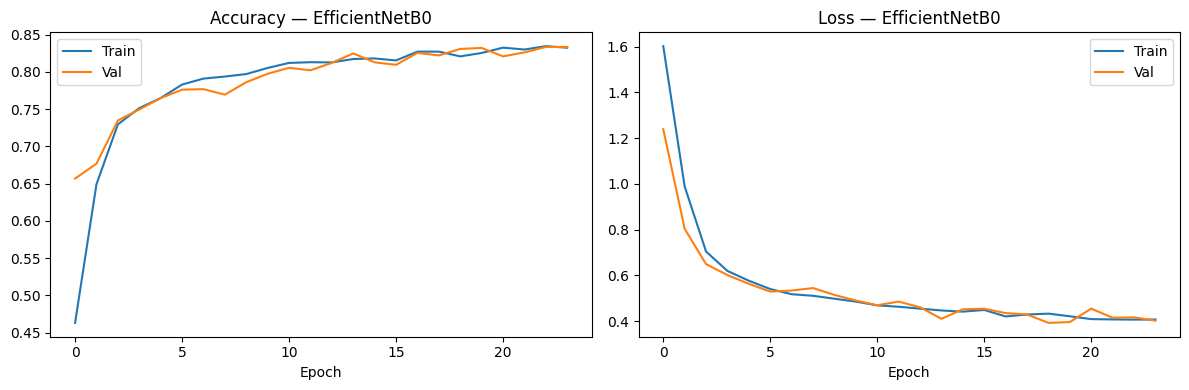

Training curves saved.
Training history saved.


In [4]:
# ================================================
# Cell 4 — Training  (AMP + early stopping + save best)
# ================================================
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_efficientnetb0_model.pth")

# ── Automatic Mixed Precision (AMP) ────────────────────────────
# Runs forward passes in float16 where safe, float32 where needed.
# GradScaler prevents float16 gradient underflow during backprop.
# Gives ~1.5-2x speedup on modern NVIDIA GPUs with no accuracy loss.
use_amp = DEVICE.type == "cuda"
scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)

# ── Early stopping state ───────────────────────────────────────
# Track best validation loss; save weights whenever val_loss improves.
best_val_loss = float('inf')
epochs_no_improve = 0
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []


# ── Training loop ──────────────────────────────────────────────
# Each epoch: (1) train one full pass, (2) validate,
# (3) check early stopping, (4) save best model if improved.
for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        # torch.no_grad() disables gradient tracking during inference,
        # reducing memory usage and speeding up evaluation.
        with torch.no_grad():
            preds = outputs.argmax(1)

        run_loss    += loss.item() * inputs.size(0)
        run_correct += (preds == labels).sum().item()
        run_total   += inputs.size(0)

    train_loss = run_loss / run_total
    train_acc  = run_correct / run_total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    # torch.no_grad() disables gradient tracking during inference,
    # reducing memory usage and speeding up evaluation.
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
            inputs = inputs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            val_loss    += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += inputs.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"[Epoch {epoch:02d}]  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    # ── Early stopping: train at least 20 epochs, then stop after 5 no-improvement epochs ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Best model saved  (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epoch < MIN_EPOCHS_BEFORE_STOP:
            print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE}, "
                  f"but continuing until at least epoch {MIN_EPOCHS_BEFORE_STOP}.")
        elif epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} after {epochs_no_improve} epochs without improvement.")
            break

print(f"\nTraining complete. Best model -> {BEST_MODEL_PATH}")


# ── Learning curves ────────────────────────────────────────────
# Plot training/validation accuracy and loss; save PNG and CSV.
# ── Learning curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_acc_hist, label='Train')
axes[0].plot(val_acc_hist, label='Val')
axes[0].set_title("Accuracy — EfficientNetB0")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(train_loss_hist, label='Train')
axes[1].plot(val_loss_hist, label='Val')
axes[1].set_title("Loss — EfficientNetB0")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Training curves saved.")

pd.DataFrame({
    "epoch": range(1, len(train_loss_hist) + 1),
    "train_loss": train_loss_hist,
    "val_loss": val_loss_hist,
    "train_acc": train_acc_hist,
    "val_acc": val_acc_hist,
}).to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
print("Training history saved.")


In [5]:
# ================================================
# Cell 5 — Model / Device / Size Summary
# ================================================
# Helper to read saved model file size in megabytes
def get_file_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2) if os.path.exists(path) else np.nan

MODEL_SIZE_MB = get_file_size_mb(BEST_MODEL_PATH)


# ── Model and device summary ───────────────────────────────────
# Captures all training environment details and model properties
# in a single CSV for reproducibility and result reporting.
summary = {
    "model": "EfficientNetB0 PyTorch",
    "device_used": str(DEVICE),
    "device_type": DEVICE.type,
    "graphics_card": gpu_name,
    "gpu_memory_gb": round(gpu_memory_gb, 3),
    "torch_version": torch.__version__,
    "cuda_version": torch.version.cuda if torch.cuda.is_available() else "N/A",
    "total_parameters": TOTAL_PARAMS,
    "trainable_parameters": TRAINABLE_PARAMS,
    "model_size_mb": round(MODEL_SIZE_MB, 3),
    "embedding_dim": EMBED_DIM,
    "batch_size": BATCH_SIZE,
    "image_size": IMG_SIZE,
    "epochs_configured": EPOCHS,
    "patience": PATIENCE,
    "min_epochs_before_stop": MIN_EPOCHS_BEFORE_STOP,
    "best_model_path": BEST_MODEL_PATH,
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(OUTPUT_DIR, "model_device_size_summary.csv"), index=False)

print("\nMODEL / DEVICE / SIZE SUMMARY")
print("=" * 70)
for k, v in summary.items():
    print(f"{k:24}: {v}")
print("=" * 70)



MODEL / DEVICE / SIZE SUMMARY
model                   : EfficientNetB0 PyTorch
device_used             : cuda
device_type             : cuda
graphics_card           : NVIDIA GeForce RTX 3050 Ti Laptop GPU
gpu_memory_gb           : 3.963
torch_version           : 2.6.0+cu124
cuda_version            : 12.4
total_parameters        : 4172290
trainable_parameters    : 4172290
model_size_mb           : 16.213
embedding_dim           : 128
batch_size              : 32
image_size              : 224
epochs_configured       : 50
patience                : 5
min_epochs_before_stop  : 20
best_model_path         : /home/jenarththan/Desktop/FYP/May11/Notebooks/EfficientNetB0_May11_Results/best_efficientnetb0_model.pth



     #    True Label    Pred Label   Correct


Inference:   0%|          | 0/94 [00:00<?, ?it/s]

     0             0             0       YES
     1             0             0       YES
     2             0           500       NO 
     3             0             0       YES
     4             0             0       YES
     5             0             0       YES
     6             0             0       YES
     7             0             0       YES
     8             0           500       NO 
     9             0             0       YES
    10             0             0       YES
    11             0           500       NO 
    12             0             0       YES
    13             0             0       YES
    14             0             0       YES
    15             0           500       NO 
    16             0             0       YES
    17             0             0       YES
    18             0             0       YES
    19             0             0       YES
    20             0             0       YES
    21             0           500       NO 
    22    

/tmp/ipykernel_16731/4083153557.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


    64             0             0       YES
    65             0             0       YES
    66             0             0       YES
    67             0             0       YES
    68             0             0       YES
    69             0             0       YES
    70             0             0       YES
    71             0             0       YES
    72             0          1000       NO 
    73             0          1000       NO 
    74             0          1000       NO 
    75             0             0       YES
    76             0             0       YES
    77             0          1000       NO 
    78             0          1000       NO 
    79             0             0       YES
    80             0             0       YES
    81             0             0       YES
    82             0             0       YES
    83             0             0       YES
    84             0             0       YES
    85             0             0       YES
    86    

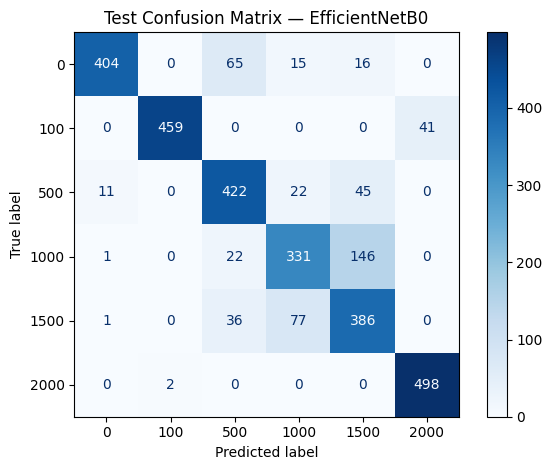


Classification Report — EfficientNetB0:
              precision    recall  f1-score   support

           0     0.9688    0.8080    0.8811       500
         100     0.9957    0.9180    0.9553       500
         500     0.7743    0.8440    0.8077       500
        1000     0.7438    0.6620    0.7005       500
        1500     0.6509    0.7720    0.7063       500
        2000     0.9239    0.9960    0.9586       500

    accuracy                         0.8333      3000
   macro avg     0.8429    0.8333    0.8349      3000
weighted avg     0.8429    0.8333    0.8349      3000



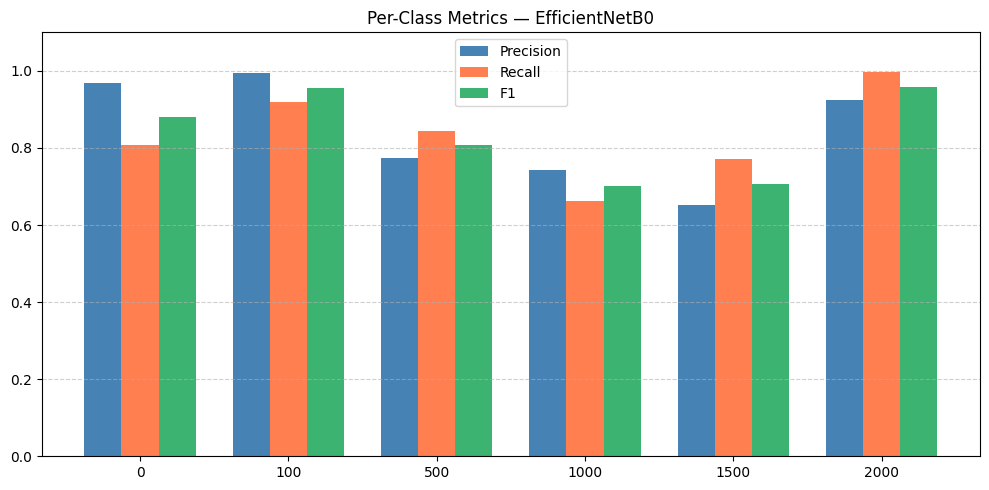

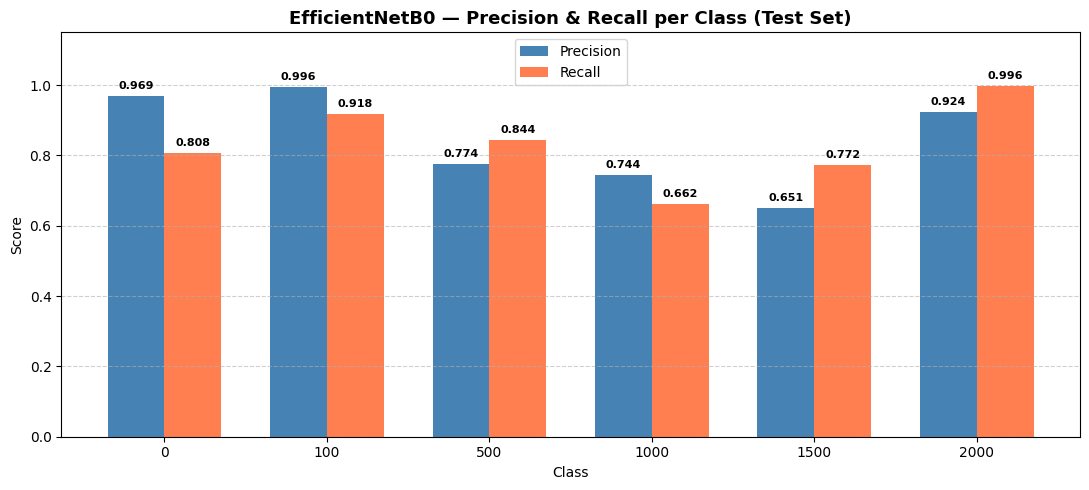

Precision & recall graph saved.


/tmp/ipykernel_16731/4083153557.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_16731/4083153557.py:137: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



EfficientNetB0 — Inference Time per Image
  Images timed : 100
  Average      : 7.142 ms / image
  Std Dev      : 0.273 ms
  Min          : 6.796 ms
  Max          : 8.558 ms

FINAL SUMMARY
Accuracy           : 83.33%
Macro Precision    : 84.29%
Macro Recall       : 83.33%
Macro F1-score     : 83.49%
Parameters         : 4,172,290 total | 4,172,290 trainable
Model size         : 16.213 MB
Inference time     : 7.142 ms/image
Device             : cuda | NVIDIA GeForce RTX 3050 Ti Laptop GPU
Results saved in: /home/jenarththan/Desktop/FYP/May11/Notebooks/EfficientNetB0_May11_Results


In [6]:
# ================================================
# Cell 6 — Test Evaluation + Reports + Graphs + Inference Time
# ================================================
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
sample_idx = 0

print("\n" + "="*65)
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)

# torch.no_grad() disables gradient tracking during inference,
# reducing memory usage and speeding up evaluation.
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference", leave=False):
        inputs = inputs.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        for i in range(len(preds)):
            true_name = CLASS_NAMES[labels[i]]
            pred_name = CLASS_NAMES[preds[i]]
            correct = "YES" if preds[i] == labels[i].item() else "NO "
            print(f"{sample_idx:>6}  {true_name:>12}  {pred_name:>12}  {correct:>8}")
            sample_idx += 1

print("="*65)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
test_acc = (all_preds == all_labels).mean()
print(f"\nTest Accuracy (EfficientNetB0): {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")


# ── Confusion matrix ───────────────────────────────────────────
# Shows predicted vs true class counts for all 6 milling classes.
# Off-diagonal entries reveal which classes are most confused.
# ── Confusion Matrix ──
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title("Test Confusion Matrix — EfficientNetB0")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_efficientnetb0.png"), dpi=150)
plt.show()


# ── Full classification report ─────────────────────────────────
# Per-class precision, recall, F1-score and support.
# Saved as both .txt (human-readable) and .csv (for analysis).
# ── Classification Report ──
report_txt = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
print("\nClassification Report — EfficientNetB0:")
print(report_txt)
with open(os.path.join(OUTPUT_DIR, "classification_report_efficientnetb0.txt"), "w") as f:
    f.write(report_txt)
report_df = pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose()
report_df.to_csv(os.path.join(OUTPUT_DIR, "classification_report_efficientnetb0.csv"))


# ── Per-class metric bar charts ────────────────────────────────
# Grouped bar charts show precision, recall and F1 for each class.
# ── Per-class metrics ──
precision = precision_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
recall = recall_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
f1 = f1_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, precision, w, label='Precision', color='steelblue')
plt.bar(x, recall, w, label='Recall', color='coral')
plt.bar(x + w, f1, w, label='F1', color='mediumseagreen')
plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.1)
plt.title("Per-Class Metrics — EfficientNetB0")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_metrics_efficientnetb0.png"), dpi=150)
plt.show()

w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, precision, w2, label='Precision', color='steelblue')
plt.bar(x + w2/2, recall, w2, label='Recall', color='coral')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, precision[i] + 0.02, f'{precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, recall[i] + 0.02, f'{recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.15)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("EfficientNetB0 — Precision & Recall per Class (Test Set)", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_efficientnetb0.png"), dpi=150)
plt.show()
print("Precision & recall graph saved.")


# ── Save raw predictions and class probabilities ───────────────
# Per-sample predictions with softmax probabilities for all 6 classes.
# ── Raw predictions CSV ──
pred_df = pd.DataFrame({
    "Sample": range(len(all_labels)),
    "True Label": [CLASS_NAMES[i] for i in all_labels],
    "Pred Label": [CLASS_NAMES[i] for i in all_preds],
    "Correct": (all_preds == all_labels).astype(int),
})
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    pred_df[f"Prob_{cls_name}"] = all_probs[:, cls_idx]
pred_df.to_csv(os.path.join(OUTPUT_DIR, "predictions_efficientnetb0.csv"), index=False)

# ================================================
# Inference Time — 100 random test samples, per image
# ================================================
num_timing = min(100, len(test_ds))
_rng100 = np.random.RandomState(SEED)
_sample_idx = _rng100.choice(len(test_ds), num_timing, replace=False)
_timing_loader = DataLoader(Subset(test_ds, _sample_idx), batch_size=1,
                            shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)

# torch.no_grad() disables gradient tracking during inference,
# reducing memory usage and speeding up evaluation.
with torch.no_grad():
    _warm, _ = next(iter(_timing_loader))
    _warm = _warm.to(DEVICE)
    with torch.cuda.amp.autocast(enabled=use_amp):
        _ = model(_warm)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

inference_times_ms = []
model.eval()
# torch.no_grad() disables gradient tracking during inference,
# reducing memory usage and speeding up evaluation.
with torch.no_grad():
    for _inp, _ in _timing_loader:
        _inp = _inp.to(DEVICE)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        _t0 = time.perf_counter()
        with torch.cuda.amp.autocast(enabled=use_amp):
            _ = model(_inp)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        inference_times_ms.append((time.perf_counter() - _t0) * 1000)

avg_time_ms = float(np.mean(inference_times_ms))
std_time_ms = float(np.std(inference_times_ms))

print("\n" + "="*58)
print("EfficientNetB0 — Inference Time per Image")
print("="*58)
print(f"  Images timed : {num_timing}")
print(f"  Average      : {avg_time_ms:.3f} ms / image")
print(f"  Std Dev      : {std_time_ms:.3f} ms")
print(f"  Min          : {np.min(inference_times_ms):.3f} ms")
print(f"  Max          : {np.max(inference_times_ms):.3f} ms")
print("="*58)

pd.DataFrame({"sample": range(num_timing), "inference_time_ms": inference_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, "efficientnetb0_inference_times.csv"), index=False)
pd.DataFrame({
    "Stage": ["EfficientNetB0"],
    "Avg_ms_per_image": [round(avg_time_ms, 4)],
    "Std_ms": [round(std_time_ms, 4)],
    "Min_ms": [round(float(np.min(inference_times_ms)), 4)],
    "Max_ms": [round(float(np.max(inference_times_ms)), 4)],
}).to_csv(os.path.join(OUTPUT_DIR, "inference_time_summary.csv"), index=False)


# ── Aggregate metrics summary ──────────────────────────────────
# Macro and weighted averages exported alongside model and device info.
# ── Final metrics summary ──
macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_recall = recall_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_precision = precision_score(all_labels, all_preds, average='weighted')
weighted_recall = recall_score(all_labels, all_preds, average='weighted')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

metrics_summary = pd.DataFrame([{
    "accuracy": test_acc,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_precision": weighted_precision,
    "weighted_recall": weighted_recall,
    "weighted_f1": weighted_f1,
    "avg_inference_ms_per_image": avg_time_ms,
    "total_parameters": TOTAL_PARAMS,
    "trainable_parameters": TRAINABLE_PARAMS,
    "model_size_mb": MODEL_SIZE_MB,
    "device_used": str(DEVICE),
    "graphics_card": gpu_name,
}])
metrics_summary.to_csv(os.path.join(OUTPUT_DIR, "metrics_summary_efficientnetb0.csv"), index=False)

print("\nFINAL SUMMARY")
print("=" * 70)
print(f"Accuracy           : {test_acc * 100:.2f}%")
print(f"Macro Precision    : {macro_precision * 100:.2f}%")
print(f"Macro Recall       : {macro_recall * 100:.2f}%")
print(f"Macro F1-score     : {macro_f1 * 100:.2f}%")
print(f"Parameters         : {TOTAL_PARAMS:,} total | {TRAINABLE_PARAMS:,} trainable")
print(f"Model size         : {MODEL_SIZE_MB:.3f} MB")
print(f"Inference time     : {avg_time_ms:.3f} ms/image")
print(f"Device             : {DEVICE} | {gpu_name}")
print("=" * 70)
print("Results saved in:", OUTPUT_DIR)


In [7]:
# ================================================
# Cell 7 — Feature Extraction  (save embeddings)
# ================================================
# ── Embedding extraction ───────────────────────────────────────
# Extracts 128-d embeddings from all splits using return_embedding=True.
# Saved as .npy files for PCA visualisation and SVM training.
def extract_embeddings(loader, model, split_name):
    model.eval()
    embs, ys = [], []
    # torch.no_grad() disables gradient tracking during inference,
    # reducing memory usage and speeding up evaluation.
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Extracting [{split_name}]", leave=False):
            inputs = inputs.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                _, emb = model(inputs, return_embedding=True)
            embs.append(emb.cpu().float().numpy())
            ys.append(labels.numpy())
    return np.concatenate(embs, axis=0), np.concatenate(ys, axis=0)

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

train_embs, train_y = extract_embeddings(train_eval_loader, model, "train")
val_embs, val_y = extract_embeddings(val_loader, model, "val")
test_embs, test_y = extract_embeddings(test_loader, model, "test")

print(f"Embedding shapes -> train: {train_embs.shape}  val: {val_embs.shape}  test: {test_embs.shape}")

for name, arr in [
    ("train_embs", train_embs), ("val_embs", val_embs), ("test_embs", test_embs),
    ("train_y", train_y), ("val_y", val_y), ("test_y", test_y),
]:
    np.save(os.path.join(OUTPUT_DIR, f"{name}.npy"), arr)
    print(f"  Saved {name}.npy  shape={arr.shape}")

print("\nAll embeddings saved.")


Extracting [train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_16731/406030973.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Extracting [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Extracting [test]:   0%|          | 0/94 [00:00<?, ?it/s]

Embedding shapes -> train: (10500, 128)  val: (1500, 128)  test: (3000, 128)
  Saved train_embs.npy  shape=(10500, 128)
  Saved val_embs.npy  shape=(1500, 128)
  Saved test_embs.npy  shape=(3000, 128)
  Saved train_y.npy  shape=(10500,)
  Saved val_y.npy  shape=(1500,)
  Saved test_y.npy  shape=(3000,)

All embeddings saved.


In [8]:
# ================================================
# Cell 8 — Saved Artifact Listing
# ================================================
# List all files saved to OUTPUT_DIR with their sizes for verification
print("\n" + "="*60)
print("EfficientNetB0 saved artifacts")
print("="*60)
for item in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, item)
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024 ** 2)
        print(f"{item:45} {size_mb:10.3f} MB")
    else:
        print(item)
print("="*60)



EfficientNetB0 saved artifacts
best_efficientnetb0_model.pth                     16.213 MB
classification_report_efficientnetb0.csv           0.001 MB
classification_report_efficientnetb0.txt           0.001 MB
confusion_matrix_efficientnetb0.png                0.051 MB
efficientnetb0_inference_times.csv                 0.002 MB
inference_time_summary.csv                         0.000 MB
metrics_summary_efficientnetb0.csv                 0.000 MB
model_device_size_summary.csv                      0.000 MB
per_class_metrics_efficientnetb0.png               0.030 MB
precision_recall_efficientnetb0.png                0.050 MB
predictions_efficientnetb0.csv                     0.186 MB
test_embs.npy                                      1.465 MB
test_y.npy                                         0.023 MB
train_embs.npy                                     5.127 MB
train_y.npy                                        0.080 MB
training_curves.png                                0.071 MB
training

Embeddings : (3000, 128)
True labels: (3000,)
Classes    : ['0', '100', '500', '1000', '1500', '2000']
PCA output : /home/jenarththan/Desktop/FYP/May11/Notebooks/EfficientNetB0_May11_Results/PCA_Analysis

Explained variance: PC1=0.587  PC2=0.219  Total=0.806


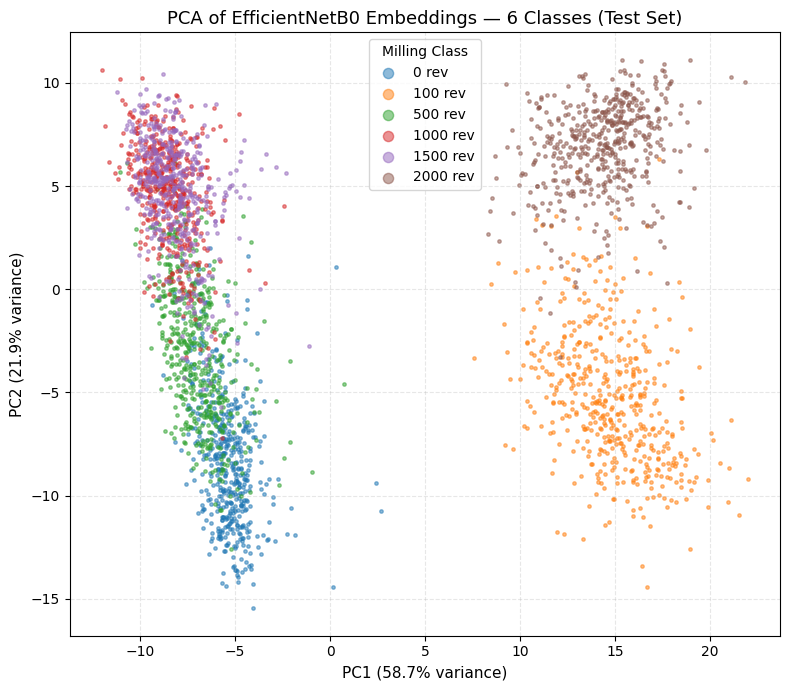

Saved: pca_embeddings.png


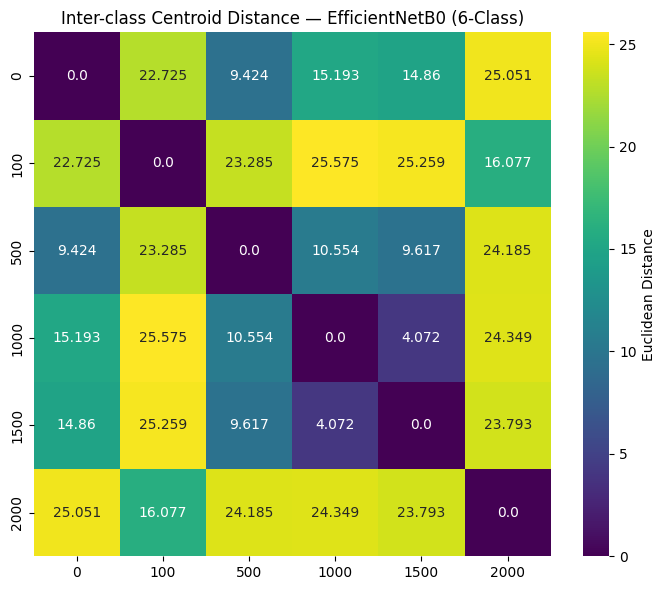

Saved: distance_heatmap.png


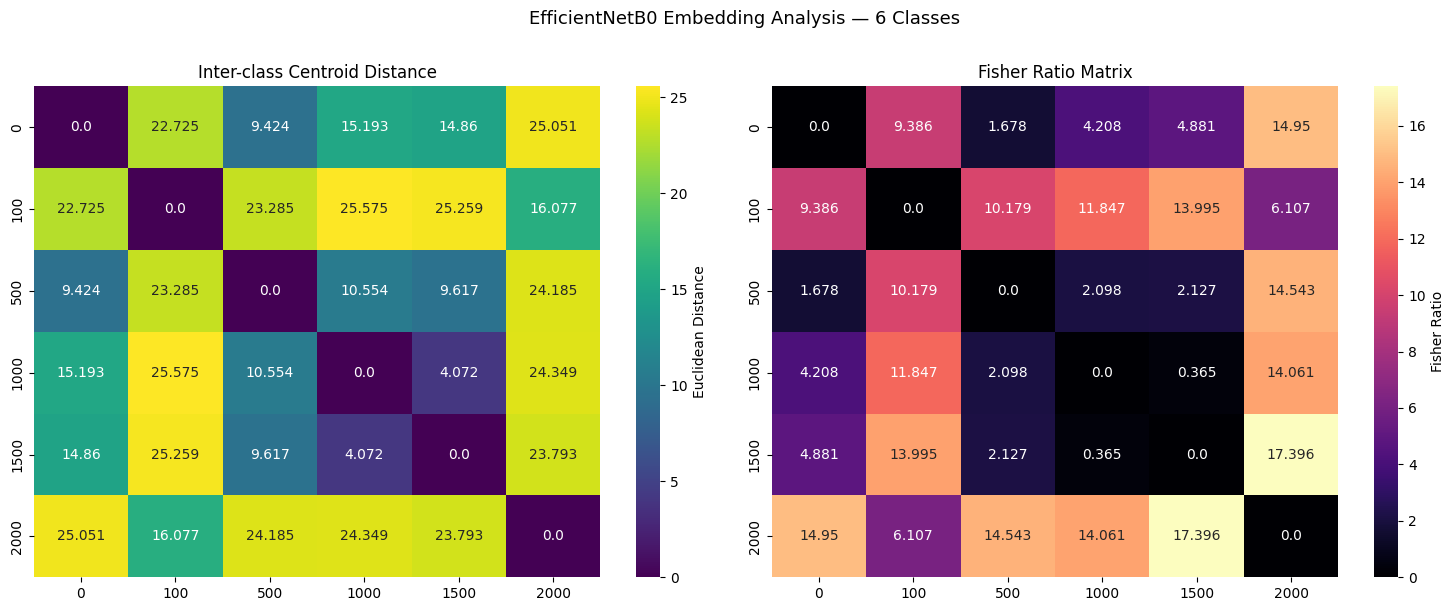

Saved: distance_fisher_side_by_side.png


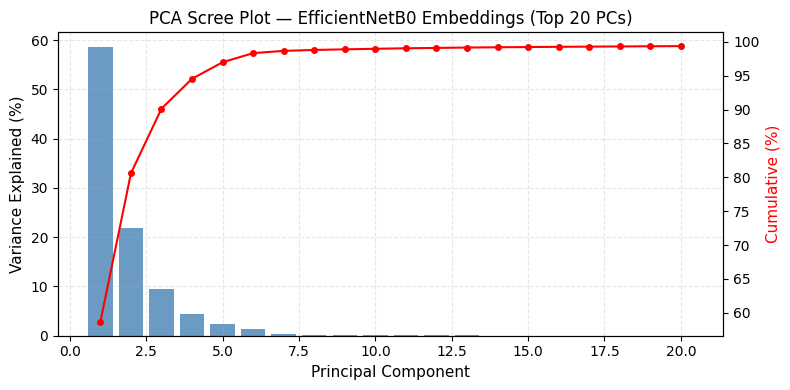

Saved: pca_scree_plot.png

All PCA results saved to: /home/jenarththan/Desktop/FYP/May11/Notebooks/EfficientNetB0_May11_Results/PCA_Analysis
PC1+PC2 explains : 80.6%
PCs for 95% var  : 5


In [9]:
# ================================================
# Cell 9 — PCA Analysis of Embeddings
# ================================================
# ── Additional libraries for PCA analysis ──────────────────────
# seaborn : heatmap visualisation for distance and Fisher matrices
# scipy   : pairwise Euclidean distances between class centroids
# sklearn.decomposition.PCA : dimensionality reduction for 2D plot
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from glob import glob

PCA_DIR = os.path.join(OUTPUT_DIR, "PCA_Analysis")
os.makedirs(PCA_DIR, exist_ok=True)


# ── Load precomputed embeddings ────────────────────────────────
# Embeddings and predictions saved by Cells 7 and 6 are loaded here
# to decouple PCA analysis from training (can re-run independently).
# Load embeddings saved by Cell 7
test_embs = np.load(os.path.join(OUTPUT_DIR, "test_embs.npy"))
y_true    = np.load(os.path.join(OUTPUT_DIR, "test_y.npy"))

# Find predictions CSV saved by Cell 6
pred_csvs = glob(os.path.join(OUTPUT_DIR, "predictions_*.csv"))
assert pred_csvs, f"No predictions CSV found in {OUTPUT_DIR}. Run Cell 6 first."
pred_df   = pd.read_csv(pred_csvs[0])
label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
y_pred = np.array([label_to_idx[str(l)] for l in pred_df["Pred Label"].values])

COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'][:NUM_CLASSES]

print(f"Embeddings : {test_embs.shape}")
print(f"True labels: {y_true.shape}")
print(f"Classes    : {CLASS_NAMES}")
print(f"PCA output : {PCA_DIR}")


# ── PCA 2-D projection ─────────────────────────────────────────
# Projects 128-d embeddings onto 2 principal components.
# Well-separated clusters indicate discriminative learned features.
# ── PCA 2D scatter ──────────────────────────────
pca = PCA(n_components=2, random_state=42)
Z   = pca.fit_transform(test_embs)
var = pca.explained_variance_ratio_
print(f"\nExplained variance: PC1={var[0]:.3f}  PC2={var[1]:.3f}  Total={var.sum():.3f}")

fig, ax = plt.subplots(figsize=(8, 7))
for i, name in enumerate(CLASS_NAMES):
    idx = (y_true == i)
    ax.scatter(Z[idx, 0], Z[idx, 1], s=6, alpha=0.5, label=f'{name} rev', color=COLORS[i])
ax.set_title(f'PCA of EfficientNetB0 Embeddings — {NUM_CLASSES} Classes (Test Set)', fontsize=13)
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)', fontsize=11)
ax.legend(markerscale=3, fontsize=10, title='Milling Class')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_embeddings.png"), dpi=300)
plt.show()
print("Saved: pca_embeddings.png")


# ── Inter-class centroid distance matrix ───────────────────────
# Euclidean distance between class mean embeddings in 128-d space.
# Large inter-class / small intra-class distances indicate good separation.
# ── Centroid distances ──────────────────────────
centroids, intra_spread = [], []
for i in range(NUM_CLASSES):
    Xc = test_embs[y_true == i]
    mu = Xc.mean(axis=0)
    centroids.append(mu)
    intra_spread.append(np.mean(np.linalg.norm(Xc - mu, axis=1)))
centroids    = np.vstack(centroids)
intra_spread = np.array(intra_spread)

inter   = cdist(centroids, centroids, metric='euclidean')
dist_df = pd.DataFrame(inter, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=ax,
            cbar_kws={'label': 'Euclidean Distance'})
ax.set_title(f'Inter-class Centroid Distance — EfficientNetB0 ({NUM_CLASSES}-Class)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_heatmap.png"), dpi=300)
plt.show()
print("Saved: distance_heatmap.png")


# ── Fisher Discriminant Ratio ──────────────────────────────────
# Fisher ratio = (inter-class distance)^2 / (sum of intra-class variances)
# High ratio means classes are well-separated relative to internal scatter.
# ── Fisher ratio ────────────────────────────────
intra_var = intra_spread ** 2
F = np.zeros((NUM_CLASSES, NUM_CLASSES))
for a in range(NUM_CLASSES):
    for b in range(NUM_CLASSES):
        if a != b:
            F[a, b] = (inter[a, b] ** 2) / (intra_var[a] + intra_var[b] + 1e-8)
fish_df = pd.DataFrame(F, index=CLASS_NAMES, columns=CLASS_NAMES)


# Combined distance + Fisher heatmaps side by side for the paper figure
# ── Side-by-side ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=axes[0],
            cbar_kws={'label': 'Euclidean Distance'})
axes[0].set_title('Inter-class Centroid Distance', fontsize=12)
sns.heatmap(fish_df.round(3), annot=True, fmt='', cmap='magma', ax=axes[1],
            cbar_kws={'label': 'Fisher Ratio'})
axes[1].set_title('Fisher Ratio Matrix', fontsize=12)
fig.suptitle(f'EfficientNetB0 Embedding Analysis — {NUM_CLASSES} Classes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_fisher_side_by_side.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: distance_fisher_side_by_side.png")


# ── PCA scree plot ─────────────────────────────────────────────
# Variance explained per component (bar) and cumulative (red line).
# Used to determine how many PCs capture 95% of embedding variance.
# ── Scree plot ──────────────────────────────────
pca_full = PCA(random_state=42).fit(test_embs)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax  = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 21), pca_full.explained_variance_ratio_[:20]*100, color='steelblue', alpha=0.8, label='Individual')
ax2 = ax.twinx()
ax2.plot(range(1, 21), cum_var[:20]*100, color='red', marker='o', ms=4, label='Cumulative')
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Variance Explained (%)', fontsize=11)
ax2.set_ylabel('Cumulative (%)', fontsize=11, color='red')
ax.set_title('PCA Scree Plot — EfficientNetB0 Embeddings (Top 20 PCs)', fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_scree_plot.png"), dpi=150)
plt.show()
print("Saved: pca_scree_plot.png")


# Export all PCA results to CSV for reproducibility and further analysis
# ── Save CSVs ───────────────────────────────────
dist_df.to_csv(os.path.join(PCA_DIR, "pairwise_centroid_distance.csv"))
fish_df.to_csv(os.path.join(PCA_DIR, "pairwise_fisher_ratio.csv"))
pd.DataFrame({'Class': CLASS_NAMES, 'Intra_spread': intra_spread.round(4),
              'N_samples': [int(np.sum(y_true == i)) for i in range(NUM_CLASSES)]
}).to_csv(os.path.join(PCA_DIR, "class_spread_summary.csv"), index=False)
pd.DataFrame({'PC1': Z[:,0], 'PC2': Z[:,1],
              'True_Label': [CLASS_NAMES[i] for i in y_true]
}).to_csv(os.path.join(PCA_DIR, "pca_coordinates.csv"), index=False)

print(f"\nAll PCA results saved to: {PCA_DIR}")
n_95 = int(np.searchsorted(cum_var, 0.95)) + 1
print(f"PC1+PC2 explains : {cum_var[1]*100:.1f}%")
print(f"PCs for 95% var  : {n_95}")